## Get Cuda and Processor information

In [28]:
import sys
sys.path.append('../Submodular')

import DeviceDir

DIR, RESULTS_DIR = DeviceDir.get_directory()
device, NUM_PROCESSORS = DeviceDir.get_device()

NUM_PROCESSORS

12

In [2]:
import multiprocessing

NUM_PROCESSORS=multiprocessing.cpu_count()
print("Cpu count: ",NUM_PROCESSORS)

Cpu count:  12


In [5]:
import sys
sys.path.append('../Submodular')

from ipynb.fs.full.Dataset import get_data,generate_synthetic
from ipynb.fs.full.Dataset import datasets as available_datasets
from ipynb.fs.full.Utils import save_plot

In [10]:
import argparse
from argparse import ArgumentParser

#set default arguments here
def get_configuration():
    parser = ArgumentParser()
    parser.add_argument('--epochs', type=int, default=1)
    parser.add_argument('--log_info', type=bool, default=True)
    parser.add_argument('--pbar', type=bool, default=False)
    parser.add_argument('--batch_size', type=int, default=2048)
    parser.add_argument('--learning_rate', type=float, default=0.01)
    parser.add_argument('--recompute', type=bool, default=False)
    parser.add_argument('--num_gpus', type=int, default=-1)
    parser.add_argument('--parallel_mode', type=str, default="dp", choices=['dp', 'ddp', 'ddp2'])
    parser.add_argument('--dataset', type=str, default="Cora", choices=available_datasets)
    parser.add_argument('--use_normalization', action='store_false', default=True)
    # parser.add_argument('-f') ##dummy for jupyternotebook
    args, unknown = parser.parse_known_args()
    
    dict_args = vars(args)
    
    return args, dict_args

args, dict_args = get_configuration()

## libraries

In [11]:
import random
import numpy as np
import torch

SYNTHETIC = True
seed = 123

data_filename_extension = ""

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
None

In [12]:
import os
import math
import time
import json
from tqdm import tqdm
import torch.nn as nn
from torch_geometric.data import Data, Dataset

## GNN model

In [13]:
import torch_geometric
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, GINConv, ChebConv
from torch_geometric.nn import GraphConv, TransformerConv
from torch_geometric.utils import degree
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score
from ags_pipeline import compute_knn_and_submodular_parallel
from pathlib import Path
from ipynb.fs.full.SpatialConv import SpatialConv

def save_weight(weight, path):
    p = Path(path)
    p.parent.mkdir(parents=True, exist_ok=True)
    torch.save(weight, p)


def load_weight(path):
    return torch.load(path, map_location='cpu')


def compute_or_load_edge_weights(data, save_dir, recompute=False, device=None):
    os.makedirs(save_dir, exist_ok=True)
    knn_path = os.path.join(save_dir, 'knn_weights.pt')
    submod_path = os.path.join(save_dir, 'submodular_weights.pt')

    if not recompute and os.path.exists(knn_path) and os.path.exists(submod_path):
        w_knn = load_weight(knn_path)
        w_sub = load_weight(submod_path)
    else:
        w_knn, w_sub = compute_knn_and_submodular_parallel(
            data,
            knn_kwargs={'metric': 'cosine', 'log': False, 'device': device},
            submod_kwargs={'metric': 'cosine', 'log': False, 'device': device},
        )
        save_weight(w_knn.cpu(), knn_path)
        save_weight(w_sub.cpu(), submod_path)

    if device is not None:
        w_knn = w_knn.to(device)
        w_sub = w_sub.to(device)

    edge_weight = (w_knn + w_sub) * 0.5
    return w_knn, w_sub, edge_weight


### GNN option 1

In [14]:
GNNconv = SAGEConv

In [15]:
# from torch_geometric.nn import GCNConv, GATConv, GINConv, SAGEConv
GNNconv2 = GATConv

class GNNother(torch.nn.Module):
    def __init__(self, num_features,num_classes, hidden_channels=256):
        super().__init__()        
        ##GNN layer
        global GNNconv2
        
        if(GNNconv2==GINConv):
            self.MLP1 = nn.Linear(num_features,hidden_channels)
            self.MLP2 = nn.Linear(hidden_channels,num_classes)
            self.conv1 = GNNconv2(self.MLP1)
            self.conv2 = GNNconv2(self.MLP2)                
        else:        
            self.conv1 = GNNconv2(num_features, hidden_channels)
            self.conv2 = GNNconv2(hidden_channels,num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight)
        x = x.relu()
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv2(x, edge_index, edge_weight)
        
        #x = x.log_softmax(dim=-1)
        #x = x.relu()
        
        return x
    

class GNNGAT(torch.nn.Module):
    def __init__(self, num_features, num_classes, hidden_channels, heads):
        super().__init__()
        self.conv1 = GATConv(num_features, hidden_channels, heads, edge_dim=1)  # TODO
        self.conv2 = GATConv(hidden_channels*heads, num_classes, heads=1, concat=True, edge_dim=1)  # TODO

    def forward(self, x, edge_index, edge_attr=None):
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv1(x, edge_index, edge_attr)
        x = F.elu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv2(x, edge_index, edge_attr)
        return x

In [26]:
class GNNHomophily(torch.nn.Module):
    def __init__(self, num_features,num_classes, hidden_channels=16):
        super().__init__()
        self.num_classes = num_classes
             
        self.conv1 = GNNconv(num_features, hidden_channels)
        #self.conv2 = GNNconv(hidden_channels,hidden_channels)
        self.conv3 = GNNconv(hidden_channels,num_classes)

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight)
        x = x.relu()
        x = F.dropout(x, p=0.2, training=self.training)
#         x = self.conv2(x, edge_index, edge_weight)
#         x = x.relu()
#         x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv3(x, edge_index, edge_weight)
        
        return x
    
class GNNHeterophily(torch.nn.Module):
    def __init__(self, num_features,num_classes, hidden_channels=16):
        super().__init__()
        self.num_classes = num_classes
             
        self.conv1 = ChebConv(num_features, hidden_channels, K=2, normalization='sym')
        #self.conv2 = GNNconv(hidden_channels,hidden_channels)
        self.conv3 = ChebConv(hidden_channels,num_classes, K=2, normalization='sym')

    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight)
        x = x.relu()
        x = F.dropout(x, p=0.2, training=self.training)
#         x = self.conv2(x, edge_index, edge_weight)
#         x = x.relu()
#         x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv3(x, edge_index, edge_weight)
        
        return x
    
class AGSGNN(torch.nn.Module):
    def __init__(self, num_features,num_classes, hidden_channels=16, dropout=0.5):
        super().__init__()
        self.num_classes = num_classes
        
        hidden = int(hidden_channels/2)        
        
        ####################
        self.gnn1 = GNNHomophily(num_features, hidden, hidden_channels)
#         self.gnn2 = GNNHomophily(num_features, hidden, hidden_channels)
        
# #         self.gnn1 = GNNHeterophily(num_features, hidden, hidden_channels)
        self.gnn2 = GNNHeterophily(num_features, hidden, hidden_channels)
        
#         ####################
#         self.gnn1 = GNNother(num_features, hidden, hidden_channels)
#         self.gnn2 = GNNother(num_features, hidden, hidden_channels)        

#         ####################
#         self.gnn1 = GNNHomophily(num_features, num_classes, hidden_channels)
#         self.gnn1 = GNNHeterophily(num_features, num_classes, hidden_channels)
        #################
    
        self.p = dropout
        self.com_lin = nn.Linear(hidden*2, num_classes)
        
        
#         self.T = 2        
#         self.layer_norm_a1 =  nn.LayerNorm(num_classes)
#         self.layer_norm_s1 =  nn.LayerNorm(num_classes)
        
#         self.alpha_a1 = nn.Linear(num_classes, 1)
#         self.alpha_s1 = nn.Linear(num_classes, 1)
#         self.w1 = nn.Linear(self.T, self.T)
        
        #self.reset_parameters()
            
#     def reset_parameters(self):
#         std_att = 1. / math.sqrt(self.w1.weight.size(1))
#         std_att_vec = 1. / math.sqrt( self.alpha_a1.weight.size(1))
        
#         self.alpha_s1.weight.data.uniform_(-std_att, std_att)
#         self.alpha_i1.weight.data.uniform_(-std_att, std_att)
        
#         self.layer_norm_a1.reset_parameters()
#         self.layer_norm_s1.reset_parameters()        
        
    def forward(self, batch_data):
        
        #out = model(batch_data.x, batch_data.edge_index, batch_data.weight)
        #out = model(batch_data.x, batch_data.edge_index, batch_data.edge_weight)
        #out = model(batch_data.x, batch_data.edge_index)
        
        x1 = self.gnn1(batch_data[0].x, batch_data[0].edge_index)
#         return x1        
        
        x2 = self.gnn2(batch_data[1].x, batch_data[1].edge_index)
        #return x2
        
        a1 = F.relu(x1)
        #a1 = self.layer_norm_a1(a1)
        a1 = F.dropout(a1, p=self.p, training=self.training)
        
        s1 = F.relu(x2)
        #s1 = self.layer_norm_s1(s1)
        s1 = F.dropout(s1, p=self.p, training=self.training)
        
        used = batch_data[0].batch_size
        
        x = torch.cat([a1[:used,:], s1[:used,:]], dim=-1)
        x = self.com_lin(x)
        
        
#         ala1 = torch.sigmoid(self.alpha_a1(a1))
#         als1 = torch.sigmoid(self.alpha_s1(s1))        
        
#         alpha1 = F.softmax(self.w1(torch.cat([ala1, als1],dim=-1)/self.T), dim=1)                
#         x = torch.mm(torch.diag(alpha1[:,0]),a1) + torch.mm(torch.diag(alpha1[:,1]),s1)
        
        #print(x.shape)
        
        return x

## GNN Training and Testing

In [31]:
from torch_geometric.loader import NeighborSampler, NeighborLoader
# from ipynb.fs.full.Submodular.AGSNodeSampler import WeightedNeighborLoader

class WeightedNeighborLoader(NeighborLoader):
    def __init__(self, *args, **kwargs):
        # Remove unsupported parameters
        kwargs.pop('weight_func', None)
        kwargs.pop('params', None)
        kwargs.pop('log', None)
        kwargs.pop('save_dir', None)
        kwargs.pop('recompute', None)
        super().__init__(*args, **kwargs)

In [34]:
def test(model, loader, mask, name='Train'):    
    if args.log_info:    
        pbar = tqdm(total=sum(mask).item())
        pbar.set_description(f'Evaluating {name}')
    
    model.eval()
    
    total_correct=0
    total_examples=0
    
    sigmoid = nn.Sigmoid()    
    
    y_true = []
    y_pred = []
    
    with torch.no_grad():                  
    
        for i,batch_data in enumerate(loader):
            
            batch_data = [batch_data, batch_data]  # For AGS-GNN
            batch_data = [b.to(device) for b in batch_data]
            used = batch_data[0].batch_size
            
            out = model(batch_data)
                   
            out=out[:used,:]
            pred = out.argmax(dim=1)            

            y_true.append(batch_data[0].y[:used].detach().cpu().numpy())
            y_pred.append(pred.detach().cpu().numpy())
            
            if args.log_info:
                pbar.update(used)
              
    if args.log_info:
        pbar.close()
    
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    
    acc = accuracy_score(y_true, y_pred)
    #acc = f1_score(y_true, y_pred, average='micro')
                    
    return acc

In [38]:
def train(DATASET_NAME, model, data, epochs=100, train_neighbors=[-1,10], test_neighbors=[-1,10]):
    
    if args.log_info:
        print("Train neighbors: ", train_neighbors)
        print("Test neighbors: ", test_neighbors)
        
#     optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    optimizer = torch.optim.Adam(model.parameters())
    
    if data.y.ndim == 1:
        criterion = torch.nn.CrossEntropyLoss()
    else:
        criterion = torch.nn.BCEWithLogitsLoss()
    
    batch_size=1024         
#     batch_size=512         
    worker = 8
    
    if data.num_nodes>=50000:
        worker = 8
    else:
        worker = min(8,int(sum(data.train_mask)/batch_size))
        
    if args.log_info:
        print("Worker: ", worker)
        
    weight_func=['knn','submodular']; 
#     weight_func=['knn','submodular']; 
#     weight_func=['random', 'random'];  worker = 0;
#     weight_func=['link-nn', 'link-sub'];  worker = 2;
    params={
        'knn':{'metric':'cosine'},
        'submodular':{'metric':'cosine'},
        'link-nn':{'value':'min'},
        'link-sub':{'value':'max'},
        'apricot':{'sub_func':'coverage','metric':'cosine'}
    }    
    
    global data_filename_extension        
#     sampler_dir = DIR+'AGSGNNstruc/'+DATASET_NAME+data_filename_extension
    sampler_dir = DIR+'AGSGNNstrucCorrect/'+DATASET_NAME+data_filename_extension
    
    if args.log_info:
        print(sampler_dir)
    
    
#     if not os.path.exists(sampler_dir):
#         os.makedirs(sampler_dir)
    
    start = time.time()    
#     loader = WeightedNeighborLoader(data, input_nodes=data.train_mask,num_neighbors=train_neighbors, 
#                               batch_size=batch_size, shuffle=True, num_workers=worker, drop_last=False, 
#                               weight_func=weight_func, params=params, log=args.log_info,
#                                     directed=True, replace = False,
#                                     save_dir = sampler_dir,recompute = args.recompute)
    
    loader = WeightedNeighborLoader(data, input_nodes=data.train_mask,num_neighbors=train_neighbors, 
                              batch_size=batch_size, shuffle=True, num_workers=worker, drop_last=False, 
                              weight_func=weight_func, params=params, log=True,
                                    directed=True, replace = False,
                                    save_dir = sampler_dir,recompute = args.recompute)

    train_loader = WeightedNeighborLoader(data, input_nodes=data.train_mask,num_neighbors=train_neighbors, 
                              batch_size=batch_size, shuffle=False, num_workers=worker, drop_last=False, 
                              weight_func=weight_func, params=params, log=args.log_info,
                                          directed=True, replace = False,
                                          save_dir = sampler_dir,recompute = False)
    
    val_loader = WeightedNeighborLoader(data, input_nodes=data.val_mask,num_neighbors=test_neighbors, 
                              batch_size=batch_size, shuffle=False, num_workers=min(8,int(sum(data.val_mask)/batch_size)), drop_last=False, 
                              weight_func=weight_func, params=params,log=args.log_info, directed=True, replace = False,
                                        save_dir = sampler_dir,recompute = False)
    
    test_loader = WeightedNeighborLoader(data, input_nodes=data.test_mask,num_neighbors=test_neighbors, 
                              batch_size=batch_size, shuffle=False, num_workers=min(8,int(sum(data.test_mask)/batch_size)), drop_last=False, 
                              weight_func=weight_func, params=params, log=args.log_info, directed=True, replace = False,
                                         save_dir = sampler_dir,recompute = False)
    
    top_k_accs = []    
    best_acc=0  
    
    train_losses=[]
    val_accuracies=[]
    train_accuracies=[]
    test_accuracies=[]
    
    num_iteration = epochs
    
    end = time.time()
    if args.log_info:
        print("Total initialization time: ", end-start)
    
    start = time.time()
    
    for epoch in range(1,epochs+1):
        
        if args.log_info:
            pbar = tqdm(total=int(sum(data.train_mask)))
            pbar.set_description(f'Epoch {epoch:02d}')
        
        model.train()
        total_loss = total_examples = 0
        
        for i,batch_data in enumerate(loader):            
            #print(batch_data)
            
            batch_data = [batch_data, batch_data]  # For AGS-GNN with two GNNs
            batch_data = [b.to(device) for b in batch_data]
            used = batch_data[0].batch_size #int(sum(batch_data.train_mask))       
            
            optimizer.zero_grad()            
            out = model(batch_data)
            #out = F.log_softmax(out, dim=1)                 
            #loss = F.nll_loss(out[batch_data[0].train_mask], batch_data[0].y[batch_data[0].train_mask])
            #loss = F.cross_entropy(out[:used], batch_data[0].y[:used])
            loss = criterion(out[:used], batch_data[0].y[:used])
            
            loss.backward()
            optimizer.step()
                        
            total_loss += loss.item() * used
            total_examples += used
            
            if args.log_info:
                pbar.update(used)
        if args.log_info:
            pbar.close()
        
        loss=total_loss / total_examples
        train_losses.append(loss)
        
        #print(f'Epoch: {epoch:03d}, Train Loss: {loss:.4f}', end = ', ')                
        
        if args.log_info:
            train_acc=test(model, train_loader,data.train_mask,'Train')            
            train_accuracies.append(train_acc.item())        
        else:
            train_acc = 0 ; train_accuracies.append(train_acc)
        
        if args.log_info:
            val_acc = test(model, val_loader,data.val_mask,'Validation')
            val_accuracies.append(val_acc.item())
        else:
            val_acc = 0 ; val_accuracies.append(val_acc)
    
        if epoch%10==0:
            test_acc = test(model, test_loader,data.test_mask,'Test')
            test_accuracies.append(test_acc.item())
        else:
            test_acc = 0
            test_accuracies.append(test_acc)
            
        
        #print(f'Epoch: {epoch:03d}, Test: {test_acc:.4f}')
        
        std_dev = np.std(train_losses[-5:])
        #print(f'Epoch: {epoch:03d}, Std dev: {std_dev:.4f}')
        
        if args.log_info:
            print(f'Epoch: {epoch:03d}, Train Loss: {loss:.4f}, Train: {train_acc:.4f}, Val: {val_acc:.4f}, Test: {test_acc:.4f}, Std dev: {std_dev:.4f}')

        if epoch>=5 and std_dev<=1e-3:
            num_iteration = epoch
            
            if args.log_info:                
                print("Iteration for convergence: ", epoch)
            break
        
    if args.log_info:
        #save_plot([val_accuracies], labels=['Validation'], name='Plots/Validation', yname='Accuracy', xname='Epoch')    
        save_plot([train_losses, train_accuracies, val_accuracies, test_accuracies], labels=['Loss','Train','Validation','Test'], name='../Results/AGSNSVal', yname='Accuracy', xname='Epoch')
        
        print ("Best Validation Accuracy, ",max(val_accuracies))
        print ("Best Test Accuracy, ",max(test_accuracies))
        
    best_acc = max(test_accuracies)
    
    end = time.time()
    if args.log_info:
        print("Total epoch time: ", end-start)    
    
    return best_acc, num_iteration

In [21]:
def AGSNSperformanceSampler(DATASET_NAME, data, dataset, num_classes, epochs=1, train_neighbors=[-1,-1], test_neighbors=[-1,-1]):        
    
    model = AGSGNN(data.x.shape[1], num_classes, hidden_channels=256).to(device)
    
    if args.log_info: print(model)    
    
    best_acc, num_iteration = train(DATASET_NAME, model, data, epochs, train_neighbors=train_neighbors, test_neighbors=test_neighbors)    
    
    return best_acc, num_iteration, model

In [22]:
def adj_feature(data):    
    adj_mat = torch.zeros((data.num_nodes,data.num_nodes))
    edges = data.edge_index.t()
    adj_mat[edges[:,0], edges[:,1]] = 1
    return adj_mat

# adj_feature(data)
# data.x.shape

In [23]:
from torch_geometric.utils import add_self_loops

# AGS-GNN Running

N  183  E  325  d  1.7759562841530054 0.06539812684059143 0.10769230872392654 0.0 -0.34627223014831543 
Data(x=[183, 1703], edge_index=[2, 325], y=[183], train_mask=[183], val_mask=[183], test_mask=[183])
AGSGNN(
  (gnn1): GNNHomophily(
    (conv1): SAGEConv(1703, 256, aggr=mean)
    (conv3): SAGEConv(256, 128, aggr=mean)
  )
  (gnn2): GNNHeterophily(
    (conv1): ChebConv(1703, 256, K=2, normalization=sym)
    (conv3): ChebConv(256, 128, K=2, normalization=sym)
  )
  (com_lin): Linear(in_features=256, out_features=5, bias=True)
)
Train neighbors:  [8, 4]
Test neighbors:  [8, 4]
Worker:  0
./Dataset/AGSGNNstrucCorrect/Texas
Total initialization time:  0.003000020980834961


Evaluating Validation: 100%|██████████| 59/59 [00:00<00:00, 3470.45it/s]


Epoch: 001, Train Loss: 1.6360, Train: 0.5747, Val: 0.5763, Test: 0.0000, Std dev: 0.0000


Evaluating Validation: 100%|██████████| 59/59 [00:00<00:00, 3528.75it/s]


Epoch: 002, Train Loss: 1.4755, Train: 0.5632, Val: 0.5593, Test: 0.0000, Std dev: 0.0803


...

Evaluating Validation: 100%|██████████| 59/59 [00:00<00:00, 706.23it/s]


Epoch: 077, Train Loss: 0.0062, Train: 1.0000, Val: 0.7966, Test: 0.0000, Std dev: 0.0010


Evaluating Validation: 100%|██████████| 59/59 [00:00<00:00, 2949.97it/s]

Epoch: 078, Train Loss: 0.0058, Train: 1.0000, Val: 0.8136, Test: 0.0000, Std dev: 0.0006
Iteration for convergence:  78


<Figure size 640x480 with 0 Axes>

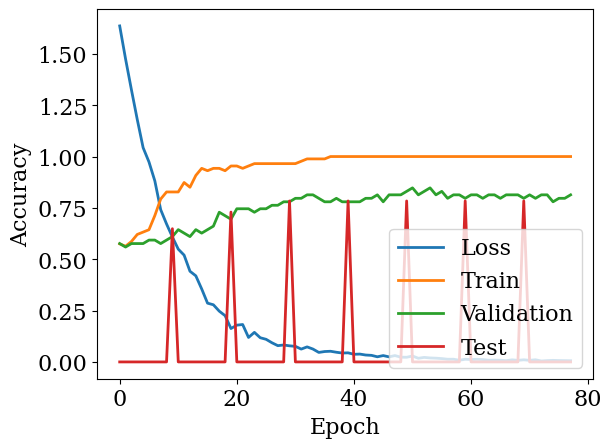

Best Validation Accuracy,  0.847457627118644
Best Test Accuracy,  0.7837837837837838
Total epoch time:  9.330110311508179
0.7837837837837838 78


In [39]:
args.log_info = True
DATASET_NAME = 'Texas'
data, dataset = get_data(DATASET_NAME, DIR='./Dataset/', log=False, h_score=True, split_no=1); print("")
print(data)

# (row, col) = data.edge_index
# data.edge_index = torch.stack((torch.cat((row, col),dim=0),torch.cat((col, row),dim=0)),dim=0)
# data.edge_index = torch_geometric.utils.coalesce(data.edge_index)
# print(data)

args.recompute = False


if len(data.y.shape) > 1:
    data.y = data.y.argmax(dim=1)        
    num_classes = torch.max(data.y).item()+1
else:
    num_classes = dataset.num_classes

if num_classes!= torch.max(data.y)+1:
    num_classes = torch.max(data.y).item()+1
    
# data.edge_index, _ = add_self_loops(data.edge_index)            
# data.x = torch.cat((data.x, adj_feature(data)), dim=1)
# if args.log_info == True:
#     print(data.x.shape)

    
# if DATASET_NAME in ['Cornell', 'cornell5']:
#     data.edge_index, _ = add_self_loops(data.edge_index)            
    
# if DATASET_NAME in ['Squirrel', 'Chameleon', 'amherst41',
#                     'Cornell','cornell5', 'johnshopkins55']:
#     data.x = torch.cat((data.x, adj_feature(data)), dim=1)
#     if args.log_info == True:
#         print(data.x.shape)


best_acc, num_iteration, _ =  AGSNSperformanceSampler(DATASET_NAME, data, dataset, num_classes, epochs=150, train_neighbors=[8,4], test_neighbors=[8,4])
print(best_acc, num_iteration)

# Batch Experiments

In [ ]:
def batch_experiments(num_run=1):
    
    ALL_DATASETs= [
        "Cornell","Texas","Wisconsin",
        "reed98","amherst41",
        "penn94","Roman-empire","cornell5","Squirrel","johnshopkins55",
        "AmazonProducts",
        "Actor","Minesweeper","Questions","Chameleon",
        "Tolokers","Flickr",
        "Yelp","Amazon-ratings","genius","cora","CiteSeer",
        "dblp","Computers","PubMed","pubmed","Reddit",
        "cora_ml","Cora","Reddit2","CS","Photo","Physics","citeseer"
    ]     
    
    ALL_DATASETs= [
        'karate',
    ]

    args.log_info = False
    
    filename = "Results/AGSGNN-NS-2.txt"
    
    for DATASET_NAME in ALL_DATASETs:  
        print(DATASET_NAME, end=' ')
        
        
        result_file = open(filename,'a+')        
        result_file.write(f'{DATASET_NAME} ')
        result_file.close()
                
        accs = []
        itrs = []
                
        for i in range(num_run):
            data, dataset = get_data(DATASET_NAME, DIR=None, log=False, h_score=False, split_no=i)   
            
            #optional for making undirected graph
            (row, col) = data.edge_index
            data.edge_index = torch.stack((torch.cat((row, col),dim=0),torch.cat((col, row),dim=0)),dim=0)
            data.edge_index = torch_geometric.utils.coalesce(data.edge_index)
            
#             if data.num_nodes>100000:
#                 accs.append(-1)
#                 itrs.append(-1)
#                 break
            
            if len(data.y.shape) > 1:
                data.y = data.y.argmax(dim=1)        
                num_classes = torch.max(data.y).item()+1
            else:
                num_classes = dataset.num_classes
            
            if num_classes!= torch.max(data.y)+1:
                num_classes = torch.max(data.y).item()+1
                
            if data.num_nodes<100000:
                max_epochs = 150
            else:
                max_epochs = 20
                
            if DATASET_NAME in ['Squirrel', 'Chameleon','cornell5','penn94','johnshopkins55'
                               "amherst41"]:
                data.x = torch.cat((data.x, adj_feature(data)), dim=1)
                if args.log_info == True:
                    print(data.x.shape)
                              
            accuracy, itr, _ = AGSNSperformanceSampler(DATASET_NAME, data, dataset, num_classes, epochs=max_epochs, train_neighbors=[8,4], test_neighbors=[8,4])
            
            accs.append(accuracy)
            itrs.append(itr)
            #print(itr, accuracy)
                        
        #print(accs, itrs)
        print(f'acc {np.mean(accs):0.4f} sd {np.std(accs):0.4f} itr {int(np.mean(itrs)):d} sd {int(np.std(itrs)):d}')
        result_file = open(filename,'a+')
        result_file.write(f'acc {np.mean(accs):0.4f} sd {np.std(accs):0.4f} itr {int(np.mean(itrs)):d} sd {int(np.std(itrs)):d}\n')
        result_file.close()
                
# batch_experiments(num_run=5)

## View Learned Representation

In [ ]:
# if __name__ == '__main__':    
    
#     n=7
#     x = torch.Tensor([[1,0],[1,0],[1,0],[0,1],[0,1],[0,1],[0,1]])
#     y = torch.LongTensor([0,0,0, 1, 1, 1, 1])
#     edge_index = torch.LongTensor([[1,2],[1,4],[1,5],[2,1],[3,6],[3,7],[4,5],[4,1],[4,6],[4,7],[5,1],[5,4],[5,6],[6,3],[6,4],[6,5],[6,7],[7,3],[7,4],[7,6]]).T
#     edge_index = edge_index-1
    
#     mask = torch.zeros(n, dtype=torch.bool)
#     mask[[1,3]] = True
    
#     test_data = Data(x = x, y = y, edge_index = edge_index, train_mask = mask, test_mask = mask, val_mask = mask)    
#     print(test_data)
    
    
#     None

In [ ]:
# from sklearn.manifold import TSNE
# import matplotlib.pyplot as plt

In [ ]:
# model.eval()
# #X = model(data.x.to(device),data.edge_index.to(device), data.weight.to(device))
# X = model(data.x.to(device),data.edge_index.to(device))
# X = X.detach().to('cpu')
# y = data.y.to('cpu')
# X.shape

In [ ]:
# plt.figure(figsize=(10, 10))

# # Create a t-SNE model with 2 components and a perplexity of 30
# tsne = TSNE(n_components=2, perplexity=30, random_state=42, learning_rate='auto', init='random')

# # Fit and transform the data to the 2D t-SNE space
# X_tsne = tsne.fit_transform(X)

# # Plot the data in the 2D t-SNE space, colored by class
# plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y)
# plt.show()

In [ ]:
## Sparsify

In [ ]:
from ipynb.fs.full.SubmodularWeights import SubModularWeightFacilityFaster
from ipynb.fs.full.KNNWeights import KNNWeight
# from ipynb.fs.full.PretrainedLink import LinkPred, LinkNN, LinkSub
from ipynb.fs.full.PretrainedLinkFast import get_link_weight, LinkNN, LinkSub
from ipynb.fs.full.RandomSparse import RandomSparse
from torch_geometric.utils import homophily
import copy
import networkx as nx
from torch_geometric.utils import to_networkx, from_networkx

In [ ]:
def sparsify(data, log = True, method = 'NN', metric= None):
    data.to('cpu')    
    
    if metric is None:
        metric = 'cosine'
    
    if method == 'nn':
        submodular_weight = KNNWeight(data, metric=metric, log=log)                
        data.weight = submodular_weight.compute_weights()        

    elif method == 'submodular':
        submodular_weight = SubModularWeightFacilityFaster(data, metric=metric, log=log)
        data.weight = submodular_weight.compute_weights()        
    
    elif method == 'link-nn':    
        submodular_weight = LinkPred(data, selfloop = True, log=log)
        data.weight = submodular_weight.compute_weights()        
        nn_weight = LinkNN(data, value='min', log=log) #min favor similar ones, max disimilar
        data.weight = nn_weight.compute_weights()
    elif method == 'link-sub':    
        nn_weight = LinkSub(data, value='max', selfloop = True, log=log) #min favor similar ones, max disimilar    
        data.weight = nn_weight.compute_weights()
    else:
        raise 'Not implemented error'
    
    cp_data= copy.deepcopy(data)
    G = to_networkx(cp_data, to_undirected=False, edge_attrs=['weight'])
    to_remove = [(a,b) for a, b, attrs in G.edges(data=True) if attrs["weight"] < 0.7 ]
    G.remove_edges_from(to_remove)
    updated_data = from_networkx(G)
    
    updated_data = from_networkx(G, group_edge_attrs=['weight'])
    updated_data.weight = updated_data.edge_attr.view(-1)

    row, col = updated_data.edge_index
    updated_data.edge_index = torch.stack((torch.cat((row, col),dim=0), torch.cat((col, row),dim=0)),dim=0)
    updated_data.weight = torch.cat((updated_data.weight, updated_data.weight),dim=0)

    
    #if args.log_info:
    if True:
        print(updated_data)
        print("Node Homophily:", homophily(updated_data.edge_index, data.y, method='node'))
        print("Edge Homophily:", homophily(updated_data.edge_index, data.y, method='edge'))
        print("Edge_insensitive Homophily:", homophily(updated_data.edge_index, data.y, method='edge_insensitive'))    
        print("Degree: ", updated_data.num_edges / updated_data.num_nodes)

    data.edge_index = updated_data.edge_index
    data.edge_weight = updated_data.weight
    data.weight = None

    return data

# LOG_INFO = True
# data = sparsify(data, log = False)
# data

In [ ]:
def random_sparsify(data, K, log = False):    
    rand_sparse = RandomSparse(data, K = K, log = log)
    edge_index = rand_sparse.sparse()
    row, col = edge_index
    data.edge_index = torch.stack((torch.cat((row, col),dim=0), torch.cat((col, row),dim=0)),dim=0)
    
    if log:
        print("Node Homophily:", homophily(data.edge_index, data.y, method='node'))
        print("Edge Homophily:", homophily(data.edge_index, data.y, method='edge'))
        print("Edge_insensitive Homophily:", homophily(data.edge_index, data.y, method='edge_insensitive'))    
        print("Degree: ", data.num_edges / data.num_nodes)
    
    return data

In [ ]:
def modify_homophily(data, h = 0.1, d = 11, log = False):
    data.to('cpu')
    N = data.num_nodes
    E = data.num_edges
    adj = SparseTensor(
        row=data.edge_index[0], col=data.edge_index[1],
        value=torch.arange(E, device=data.edge_index.device),
        sparse_sizes=(N, N))
    
    edge_index=[]
    
#     h = 0.1
#     d = 11

    match = int(round(d*h))
    unmatch = int(round(d*(1-h)))
    #print(match,unmatch)
    
    for u in range(N):                
        row, col, e_index = adj[u,:].coo()   
        
        cur_y = data.y[u]
        neighbors = data.y[col]
        #print(cur_y, neighbors)
        
        match_indexs = torch.nonzero(neighbors == cur_y).squeeze()
        other_indexs = torch.nonzero(neighbors != cur_y).squeeze()
        
        #print(match_indexs, other_indexs)
        
        if match_indexs.dim()>0:
            m_sel = match_indexs[np.random.choice(len(match_indexs), size=min(match,len(match_indexs)), replace = False)]
        else:
            m_sel = torch.LongTensor([])
        if other_indexs.dim()>0:
            um_sel = other_indexs[np.random.choice(len(other_indexs), size=min(unmatch, len(other_indexs)), replace = False)]
        else:
            um_sel = torch.LongTensor([])
            
        
        #print(m_sel, um_sel)
        
        indexs = torch.cat((m_sel,um_sel),dim=0)
    
        e_index = e_index[indexs]            
        edge_index.extend(e_index)
        
        #break        
            
    edge_index = data.edge_index[:,edge_index]
    row, col = edge_index
    data.edge_index = torch.stack((torch.cat((row, col),dim=0), torch.cat((col, row),dim=0)),dim=0)
    
    if log:
        print("Node Homophily:", homophily(data.edge_index, data.y, method='node'))
        print("Edge Homophily:", homophily(data.edge_index, data.y, method='edge'))
        print("Edge_insensitive Homophily:", homophily(data.edge_index, data.y, method='edge_insensitive'))    
        print("Degree: ", data.num_edges / data.num_nodes)
    
    return data

# data = modify_homophily(data, h=0.15, d=11, log = True)
# data

In [ ]:
def test_hetero():
    d = 42
    for h in np.array(range(0,21))/20:
        DATASET_NAME = 'squirrel'
        data, dataset = get_data(DATASET_NAME, log=False)
        data = generate_synthetic(data, d=d, h = h, train=0.6, random_state=1, log=False, balance = False)
        num_classes = dataset.num_classes
        
        print('d ', d, ' h', h, end=' ')
        count, score = test_uniformity(data, num_classes, log=False)
        print(count, score, end = ' ')
        total_en, en_score = total_entropy(data, num_classes, log=False)
        print(total_en, en_score, end = ' ')
        
        print('sparse', end = ' ')
        data = sparsify(data, log=False)
        
        count, score = test_uniformity(data, num_classes, log=False)
        print(count, score, end = ' ')
        total_en, en_score = total_entropy(data, num_classes, log=False)
        print(total_en, en_score, end = ' ')
        
        print("Nh ", homophily(data.edge_index, data.y, method='node'), end = ' ')
        print("Eh ", homophily(data.edge_index, data.y, method='edge'), end = ' ')
        print("EiH ", homophily(data.edge_index, data.y, method='edge_insensitive'), end = ' ')    
        
#         print("Ha ", agg_homophily(data, 'affinity'), end = ' ')
#         print("Hl ", agg_homophily(data, 'laplacian'), end =' ')
        
        print("D ", data.num_edges / data.num_nodes, end = '\n')


# LOG_INFO = False
# test_hetero()

# Ablation studies

In [ ]:
from ipynb.fs.full.Dataset import generate_synthetic2homophily

In [ ]:
def ablation(num_run = 1):
    
    #SYN_NAME = random.randint(0,1000)

#     ALL_DATASETs= [
#         'Wisconsin',
#         'reed98',        
#         'Roman-empire',
#         'Actor',
#         'Minesweeper',        
#         'Tolokers'
#     ]

    ALL_DATASETs= [
        "reed98",
        "amherst41",
#         "penn94",
        "cornell5",
        "Squirrel",
        "johnshopkins55",
        "Chameleon",
#         "Tolokers",
#         "Flickr",
        
#         "Computers",
#         "Photo",
#         "Physics",
        
#         "AmazonProducts",
#         "Yelp",
#         'pokec',
#         'twitch-gamer',
#         'wiki',        
        
#         "Reddit",
#         "Reddit2",
    ]
    

    
#     ALL_DATASETs= ["Cora"]
    
    args.log_info = False    
    
    filename = "Results/AGSGNN-NS-2Ablation.txt"
    
    for DATASET_NAME in ALL_DATASETs:  
        
        random_state = 10
        #args.recompute = True
        
        print(DATASET_NAME,"-",random_state, end=' ')
        
        
        result_file = open(filename,'a+')        
        result_file.write(f'{DATASET_NAME} ')
        result_file.close()
                
        accs = []
        itrs = []
                
        for i in range(num_run):
            data, dataset = get_data(DATASET_NAME, DIR=None, log=False, h_score=False, split_no=i)   
            
            d = 100
            h =0.50
            train=0.1
            balance=True
            h2 = 0.25
            ratio = 0.50
                                    
#             global data_filename_extension
#             data_filename_extension = str(d)+str(h)+str(train)+str(random_state)+str(balance)+'.weight'            
#             data_filename = DIR+'AGSGNNstruc/'+DATASET_NAME+str(d)+str(h)+str(train)+str(random_state)+str(balance)
            
#             if os.path.exists(data_filename):
#                 data = torch.load(data_filename)                
#                 print("loaded "+data_filename)
#             else:
#                 data = generate_synthetic(data, d=d, h=h, train=train, random_state=random_state, log=False, balance=balance)
# #                 data = generate_synthetic(data, d=d, h=h, train=train, random_state=random_state, log=False)
#                 torch.save(data,data_filename)
#                 print("saved "+data_filename)
        
#             global data_filename_extension
#             data_filename_extension = str(d)+str(h)+str(h2)+str(ratio)+str(train)+str(random_state)+str(balance)+'.weight'            
#             data_filename = DIR+'AGSGNNstruc/'+DATASET_NAME+str(d)+str(h)+str(h2)+str(ratio)+str(train)+str(random_state)+str(balance)
            
#             if os.path.exists(data_filename):
#                 data = torch.load(data_filename)                
#                 print("loaded "+data_filename)
#             else:
#                 data = generate_synthetic2homophily(data, d=d, h1=h, h2=h2, ratio=ratio, train=train, random_state=random_state, log=False, balance=balance)                 
#                 torch.save(data,data_filename)
#                 print("saved "+data_filename)
    
            ##Sparsifiy
            #data = random_sparsify(data, 13, log = True)
#             data = sparsify(data, log = True, method = 'submodular', metric= 'cosine')
                        
#             data1 = sparsify(copy.deepcopy(data), log = True, method = 'submodular', metric= 'cosine')
#             data = sparsify(data, log = True, method = 'nn', metric= 'cosine')                         
#             data.edge_index = torch.cat((data.edge_index, data1.edge_index), dim=1)
            
            #optional for making undirected graph
            (row, col) = data.edge_index
            data.edge_index = torch.stack((torch.cat((row, col),dim=0),torch.cat((col, row),dim=0)),dim=0)
            data.edge_index = torch_geometric.utils.coalesce(data.edge_index)
            
            if args.log_info:
                print("Node Homophily:", homophily(data.edge_index, data.y, method='node'))
                print("Edge Homophily:", homophily(data.edge_index, data.y, method='edge'))
                print("Edge_insensitive Homophily:", homophily(data.edge_index, data.y, method='edge_insensitive'))    
                print("Degree: ", data.num_edges / data.num_nodes)

            
#             if data.num_nodes>100000:
#                 accs.append(-1)
#                 itrs.append(-1)
#                 break
            
            if len(data.y.shape) > 1:
                data.y = data.y.argmax(dim=1)        
                num_classes = torch.max(data.y).item()+1
            else:
                num_classes = dataset.num_classes
            
            if num_classes!= torch.max(data.y)+1:
                num_classes = torch.max(data.y).item()+1
                
            if data.num_nodes<100000:
                max_epochs = 500
            else:
                max_epochs = 20
                
            if DATASET_NAME in ['Squirrel', 'Chameleon','cornell5','penn94','johnshopkins55','amherst41']:
                data.x = torch.cat((data.x, adj_feature(data)), dim=1)
                if args.log_info == True:
                    print(data.x.shape)

#             accuracy, itr = 0,0
            
#             accuracy, itr, mdl = AGSNSperformanceSampler(DATASET_NAME, data, dataset, num_classes, epochs=max_epochs, train_neighbors=[25,25], test_neighbors=[25,25])        
            accuracy, itr, mdl = AGSNSperformanceSampler(DATASET_NAME, data, dataset, num_classes, epochs=max_epochs, train_neighbors=[8,4], test_neighbors=[8,4])            
#             accuracy, itr, mdl = AGSNSperformanceSampler(DATASET_NAME, data, dataset, num_classes, epochs=max_epochs, train_neighbors=[4,4], test_neighbors=[4,4])            
#             accuracy, itr, mdl = AGSNSperformanceSampler(DATASET_NAME, data, dataset, num_classes, epochs=max_epochs, train_neighbors=[-1,-1], test_neighbors=[-1,-1])
            
            #print(mdl)
            #args.recompute = False
    
            accs.append(accuracy)
            itrs.append(itr)
            #print(itr, accuracy)
                        
        print(accs, itrs)
        print(DATASET_NAME,"-",random_state, end=' ')
        print(f'acc {np.mean(accs)*100:0.4f} sd {np.std(accs)*100:0.4f} itr {int(np.mean(itrs)):d} sd {int(np.std(itrs)):d}')
        result_file = open(filename,'a+')
        result_file.write(f'acc {np.mean(accs)*100:0.4f} sd {np.std(accs)*10:0.4f} itr {int(np.mean(itrs)):d} sd {int(np.std(itrs)):d}\n')
        result_file.close()
                
    return 

# st_time = time.time()
# ablation(num_run=3)
# en_time = time.time()

# print("Runtime: ", en_time-st_time)

reed98 - 10 Loading weights  knncosine
Loading weights  knncosine
Loading weights  knncosine
[0.6528497409326425, 0.6528497409326425, 0.6424870466321243] [107, 117, 195]
reed98 - 10 acc 64.9396 sd 0.4885 itr 139 sd 39
amherst41 - 10 Loading weights  knncosine
Loading weights  knncosine
Loading weights  knncosine
[0.7762863534675615, 0.7785234899328859, 0.785234899328859] [61, 59, 50]
amherst41 - 10 acc 78.0015 sd 0.3802 itr 56 sd 4
cornell5 - 10 Metric:  cosine
Pool Size:  32


Nodes: 100%|██████████| 18660/18660 [00:22<00:00, 843.10it/s] 


saving weights  knncosine
Loading weights  knncosine
Loading weights  knncosine
[0.7722400857449089, 0.7805466237942122, 0.7751875669882101] [28, 48, 40]
cornell5 - 10 acc 77.5991 sd 0.3438 itr 38 sd 8
Squirrel - 10 Metric:  cosine


Nodes: 100%|██████████| 5201/5201 [00:07<00:00, 716.49it/s] 


saving weights  knncosine
Loading weights  knncosine
Loading weights  knncosine
[0.6839577329490875, 0.6791546589817483, 0.654178674351585] [76, 82, 87]
Squirrel - 10 acc 67.2430 sd 1.3054 itr 81 sd 4
johnshopkins55 - 10 Metric:  cosine


Nodes: 100%|██████████| 5180/5180 [00:07<00:00, 663.32it/s]


saving weights  knncosine
Loading weights  knncosine
Loading weights  knncosine
[0.7847490347490348, 0.7722007722007722, 0.7673745173745173] [59, 50, 56]
johnshopkins55 - 10 acc 77.4775 sd 0.7323 itr 55 sd 3
Chameleon - 10 Metric:  cosine


Nodes: 100%|██████████| 2277/2277 [00:01<00:00, 1696.68it/s]


saving weights  knncosine
Loading weights  knncosine
Loading weights  knncosine
[0.7192982456140351, 0.7456140350877193, 0.7039473684210527] [134, 130, 141]
Chameleon - 10 acc 72.2953 sd 1.7206 itr 135 sd 4
Runtime:  2593.0342602729797
